In [12]:
import json
from pathlib import Path

import pandas as pd
import numpy as np
from matplotlib import pyplot as plt

from sklearn.metrics import accuracy_score

In [89]:
plt.style.use("../clane.mplstyle")
PLOTW = 3.25  # 6.75 two column width, 0.25 pad
plt.rcParams["figure.dpi"] = 300

In [21]:
paths = sorted(Path("output").rglob("train_log.json"))
print(len(paths))

tables = []
for path in paths:
    tables.append(pd.read_json(path, lines=True))
table = pd.concat(tables, ignore_index=True)
print(table.shape)
table.head()

42
(4200, 8)


,model,repr,clf,dataset,trial_id,C,split,acc
0,brain_harmonix_f,patch,logistic,aabc_age,0,0.000774,test,0.357143
1,brain_harmonix_f,patch,logistic,aabc_age,1,2.782559,test,0.321429
2,brain_harmonix_f,patch,logistic,aabc_age,2,0.359381,test,0.357143
3,brain_harmonix_f,patch,logistic,aabc_age,3,0.000100,test,0.380952
4,brain_harmonix_f,patch,logistic,aabc_age,4,0.000100,test,0.315476


In [22]:
summary = table.loc[table["split"] == "test"].pivot_table(
    values="acc", index=["model"], columns="dataset", aggfunc=["mean", "std"]
)
summary

mean                                 \
dataset                  aabc_age  aabc_sex  abide_dx adhd200_dx   
model                                                              
brain_harmonix_f         0.363512  0.580341  0.540524   0.605504   
brain_jepa_vitb_ep300    0.263333  0.576591  0.538065   0.613101   
brain_semantoks          0.446071  0.802216  0.583185   0.585426   
brainlm_vitmae_111m      0.433690  0.664261  0.546169   0.596357   
connectome_schaefer400   0.447738  0.809432  0.603226   0.591783   
flat_mae_base_patch16_2  0.431250  0.873920  0.583629   0.590775   
swift                    0.378631  0.748920  0.543105   0.609380   

                                                             std            \
dataset                 hcpya_rest1lr_gender   ppmi_dx  aabc_age  aabc_sex   
model                                                                        
brain_harmonix_f                    0.783333  0.606231  0.028830  0.030911   
brain_jepa_vitb_ep300               0.806556  0.611106  0.030482  0.011146   
brain_semantoks                     0.783778  0.610402  0.032732  0.026425   
brainlm_vitmae_111m                 0.820556  0.618693  0.032083  0.031775   
connectome_schaefer400              0.778722  0.626181  0.032598  0.028728   
flat_mae_base_patch16_2             0.848667  0.642613  0.030800  0.024237   
swift                               0.822000  0.605578  0.029863  0.031873   

                                                                             
dataset                  abide_dx adhd200_dx hcpya_rest1lr_gender   ppmi_dx  
model                                                                        
brain_harmonix_f         0.023577   0.038640             0.026249  0.017691  
brain_jepa_vitb_ep300    0.024155   0.032501             0.027540  0.022221  
brain_semantoks          0.027129   0.037193             0.026727  0.019787  
brainlm_vitmae_111m      0.010064   0.035366             0.029487  0.017644  
connectome_schaefer400   0.028952   0.041654             0.029735  0.026339  
flat_mae_base_patch16_2  0.029921   0.036829             0.024847  0.024171  
swift                    0.023044   0.037750             0.024592  0.023521

In [41]:
# get earlier attn probe results
paths = sorted(Path("../260122/output").rglob("eval_table.csv"))
print(len(paths))

tables = []
for path in paths:
    tables.append(pd.read_csv(path))
attn_table = pd.concat(tables, ignore_index=True)
print(attn_table.shape)
attn_table.head()

245
(741, 16)


,model,repr,clf,dataset,C,split,acc,acc_std,f1,f1_std,epoch,lr,wd,hparam_id,hparam,loss
0,brain_harmonix_f,patch,logistic,aabc_age,0.000774,train,0.529670,0.020849,0.518920,0.021122,NaN,NaN,NaN,NaN,NaN,NaN
1,brain_harmonix_f,patch,logistic,aabc_age,0.000774,validation,0.339623,0.062557,0.331335,0.063038,NaN,NaN,NaN,NaN,NaN,NaN
2,brain_harmonix_f,patch,logistic,aabc_age,0.000774,test,0.326923,0.057734,0.298784,0.051598,NaN,NaN,NaN,NaN,NaN,NaN
3,brain_jepa_vitb_ep300,patch,logistic,aabc_age,21.544347,train,1.000000,0.000000,1.000000,0.000000,NaN,NaN,NaN,NaN,NaN,NaN
4,brain_jepa_vitb_ep300,patch,logistic,aabc_age,21.544347,validation,0.207547,0.056111,0.209413,0.055574,NaN,NaN,NaN,NaN,NaN,NaN


In [42]:
attn_summary = attn_table.loc[attn_table["split"] == "test"].pivot_table(
    values=["acc", "acc_std"], index=["model", "repr", "clf"], columns="dataset"
)
attn_summary

acc                      \
dataset                                 aabc_age  aabc_sex abide_age   
model                   repr  clf                                      
brain_harmonix_f        patch attn      0.269231  0.745455  0.612903   
                              linear    0.250000  0.618182  0.588710   
                              logistic  0.326923  0.527273  0.693548   
brain_jepa_vitb_ep300   patch attn      0.288462  0.618182  0.677419   
                              linear    0.269231  0.527273  0.677419   
                              logistic  0.307692  0.490909  0.637097   
brain_semantoks         patch attn      0.566038  0.741379  0.443548   
                              linear    0.566038  0.862069  0.556452   
                              logistic  0.622642  0.879310  0.580645   
brainlm_vitmae_111m     patch attn      0.307692  0.709091  0.620968   
                              linear    0.288462  0.672727  0.564516   
                              logistic  0.480769  0.600000  0.701613   
connectome_schaefer400  cls   linear    0.326923  0.727273  0.588710   
                              logistic  0.307692  0.781818  0.604839   
flat_mae_base_patch16_2 patch attn      0.250000  0.927273  0.612903   
                              logistic  0.423077  0.927273  0.693548   
identity_schaefer400    patch mlp       0.365385  0.818182  0.661290   
swift                   patch attn      0.377358  0.620690  0.725806   
                              logistic  0.339623  0.741379  0.677419   

                                                                         \
dataset                                 abide_dx adhd200_dx adhd200_sex   
model                   repr  clf                                         
brain_harmonix_f        patch attn      0.483871   0.584615    0.507692   
                              linear    0.395161   0.538462    0.553846   
                              logistic  0.475806   0.553846    0.553846   
brain_jepa_vitb_ep300   patch attn      0.548387   0.523077    0.538462   
                              linear    0.620968   0.492308    0.584615   
                              logistic  0.596774   0.569231    0.661538   
brain_semantoks         patch attn      0.500000   0.600000    0.646154   
                              linear    0.580645   0.569231    0.676923   
                              logistic  0.580645   0.553846    0.630769   
brainlm_vitmae_111m     patch attn      0.475806   0.492308    0.600000   
                              linear    0.475806   0.492308    0.553846   
                              logistic  0.556452   0.538462    0.553846   
connectome_schaefer400  cls   linear    0.620968   0.446154    0.676923   
                              logistic  0.588710   0.553846    0.630769   
flat_mae_base_patch16_2 patch attn      0.612903   0.584615    0.646154   
                              logistic  0.588710   0.553846    0.646154   
identity_schaefer400    patch mlp       0.669355   0.538462    0.676923   
swift                   patch attn      0.467742   0.415385    0.584615   
                              logistic  0.564516   0.569231    0.569231   

                                                                \
dataset                                adni_ad_vs_cn  adni_sex   
model                   repr  clf                                
brain_harmonix_f        patch attn          0.659091  0.507692   
                              linear        0.613636  0.630769   
                              logistic      0.636364  0.615385   
brain_jepa_vitb_ep300   patch attn          0.704545  0.800000   
                              linear        0.590909  0.723077   
                              logistic      0.681818  0.723077   
brain_semantoks         patch attn          0.613636  0.553846   
                              linear        0.613636  0.553846   
                              logistic      0.681818  0.523077   
brainlm_vitmae_11

In [43]:
# get chance level
pred_paths = sorted(
    Path("../260122/output/eval_probe").glob(
        "*__connectome_schaefer400__cls__linear/preds_test.npz"
    )
)

chance_accs = {}
for path in pred_paths:
    ds = path.parts[-2].split("__")[0]
    npz = np.load(path)
    targets = npz["targets"]
    labels, counts = np.unique(targets, return_counts=True)
    preds = np.full_like(targets, labels[counts.argmax()])
    chance_accs[ds] = accuracy_score(targets, preds)
print(json.dumps(chance_accs, indent=4))

{
    "aabc_age": 0.2692307692307692,
    "aabc_sex": 0.6,
    "abide_age": 0.3467741935483871,
    "abide_dx": 0.5403225806451613,
    "adhd200_dx": 0.5692307692307692,
    "adhd200_sex": 0.5692307692307692,
    "adni_ad_vs_cn": 0.5681818181818182,
    "adni_sex": 0.5076923076923077,
    "hcpya_rest1lr_age": 0.40384615384615385,
    "hcpya_rest1lr_gender": 0.5,
    "hcpya_task21": 0.17063492063492064,
    "nsd_cococlip": 0.06419294990723562,
    "ppmi_dx": 0.63,
    "ppmi_sex": 0.62
}


In [44]:
MODEL_NAMES = {
    "connectome_schaefer400": "Connectome",
    "identity_schaefer400": "MLP",
    "brainlm_vitmae_111m": "BrainLM",
    "brain_jepa_vitb_ep300": "Brain-JEPA",
    "brain_harmonix_f": "BrainHarmonix-F",
    "brain_semantoks": "Brain-Semantoks",
    "swift": "SwiFT",
    "flat_mae_base_patch16_2": "flat-MAE",
}

MODEL_COLORS = {model: plt.cm.tab10.colors[ii] for ii, model in enumerate(MODEL_NAMES)}

DATASET_NAMES = {
    "abide_dx": "ABIDE Dx",
    "abide_age": "ABIDE Age",
    "abide_sex": "ABIDE Sex",
    "adhd200_dx": "ADHD200 Dx",
    "adhd200_sex": "ADHD200 Sex",
    "adni_ad_vs_cn": "ADNI Dx",
    "adni_sex": "ADNI Sex",
    "ppmi_dx": "PPMI Dx",
    "ppmi_sex": "PPMI Sex",
    "ppmi_age": "PPMI Age",
    "hcpya_rest1lr_gender": "HCP-YA Sex",
    "hcpya_rest1lr_age": "HCP-YA Age",
    "hcpya_rest1lr_neofacn": "HCP-YA NEO-N",
    "aabc_sex": "HCP-A Sex",
    "aabc_age": "HCP-A Age",
    "hcpya_task21": "HCP-YA Task21",
    "nsd_cococlip": "NSD COCO24",
}

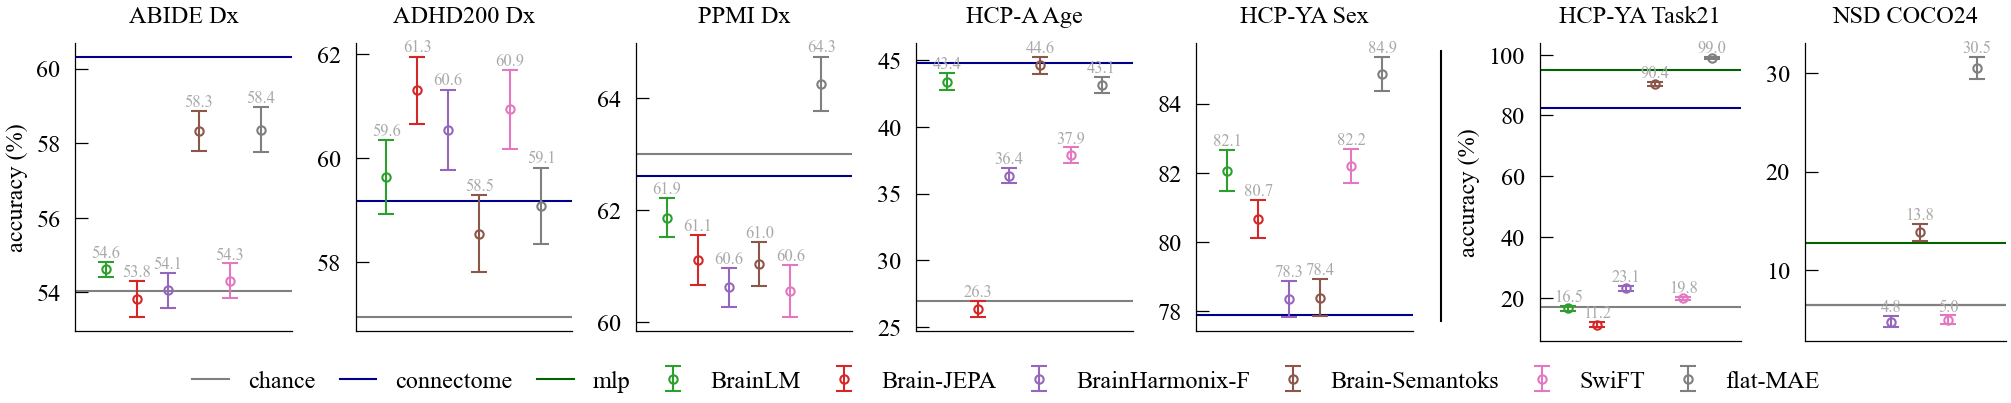

In [91]:
# probe accuracy figure

from matplotlib.ticker import FormatStrFormatter

models = [
    "brainlm_vitmae_111m",
    "brain_jepa_vitb_ep300",
    "brain_harmonix_f",
    "brain_semantoks",
    "swift",
    "flat_mae_base_patch16_2",
]

trait_datasets = ["abide_dx", "adhd200_dx", "ppmi_dx", "aabc_age", "hcpya_rest1lr_gender"]
state_datasets = ["hcpya_task21", "nsd_cococlip"]

fig = plt.figure(figsize=(2 * PLOTW + 0.25, 1.2), layout="constrained")
subfigs = fig.subfigures(1, 2, wspace=0.02, width_ratios=[len(trait_datasets), len(state_datasets)])

axs_l = subfigs[0].subplots(1, len(trait_datasets))

n_trials = 100

# Store handles for legend
handles = {}

for ii, (ax, ds) in enumerate(zip(axs_l, trait_datasets)):
    plt.sca(ax)
    handles["connectome"] = plt.axhline(
        100 * summary.loc["connectome_schaefer400", ("mean", ds)], color="darkblue", lw=0.5
    )
    if ds not in {"hcpya_rest1lr_gender"}:
        handles["chance"] = plt.axhline(100 * chance_accs[ds], color="gray", lw=0.5)

    for jj, model in enumerate(models):
        try:
            acc = summary.loc[model, ("mean", ds)]
            std = summary.loc[model, ("std", ds)]
        except KeyError:
            continue

        acc_pct = acc * 100 if not pd.isna(acc) else np.nan
        std_pct = std * 100 if not pd.isna(std) else np.nan
        ci_pct = 2 * std_pct / np.sqrt(n_trials)  # stderror

        color = MODEL_COLORS[model]
        label = MODEL_NAMES.get(model, model)

        # Plot dot with error bar
        handles[label] = ax.errorbar(
            jj,
            acc_pct,
            yerr=ci_pct,
            fmt="o",
            color=color,
            capsize=2,
            capthick=0.5,
            elinewidth=0.5,
            ms=2,
            mfc="none",
            mew=0.5,
        )
        ax.text(
            jj,
            acc_pct + 1.02 * ci_pct,
            f"{acc_pct:.1f}",
            fontsize=4,
            color="darkgray",
            ha="center",
            va="bottom",
        )

    ax.set_title(DATASET_NAMES.get(ds, ds), fontsize="small", pad=5)
    ax.set_xticks([])  # hide x ticks since we have legend
    if ii == 0:
        ax.set_ylabel("accuracy (%)", fontsize="small")
    # ax.grid(True, alpha=0.3, axis='y')
    ax.yaxis.set_major_formatter(FormatStrFormatter("%.0f"))
    ax.set_xlim(-1, len(models))

# subfigs[0].suptitle("Trait prediction (logistic probe)", fontsize="medium")

axs_r = subfigs[1].subplots(1, len(state_datasets))

for ii, (ax, ds) in enumerate(zip(axs_r, state_datasets)):
    plt.sca(ax)
    handles["connectome"] = plt.axhline(
        100 * attn_summary.loc[("connectome_schaefer400", "cls", "linear"), ("acc", ds)],
        color="darkblue",
        lw=0.5,
    )
    handles["mlp"] = plt.axhline(
        100 * attn_summary.loc[("identity_schaefer400", "patch", "mlp"), ("acc", ds)],
        color="darkgreen",
        lw=0.5,
    )
    if ds not in {"hcpya_rest1lr_gender"}:
        handles["chance"] = plt.axhline(100 * chance_accs[ds], color="gray", lw=0.5)

    for jj, model in enumerate(models):
        try:
            acc = attn_summary.loc[(model, "patch", "attn"), ("acc", ds)]
            std = attn_summary.loc[(model, "patch", "attn"), ("acc_std", ds)]
        except KeyError:
            continue

        acc_pct = acc * 100 if not pd.isna(acc) else np.nan
        std_pct = std * 100 if not pd.isna(std) else np.nan
        ci_pct = 2 * std_pct

        color = MODEL_COLORS[model]
        label = MODEL_NAMES.get(model, model)

        # Plot dot with error bar
        handles[label] = ax.errorbar(
            jj,
            acc_pct,
            yerr=ci_pct,
            fmt="o",
            color=color,
            capsize=2,
            capthick=0.5,
            elinewidth=0.5,
            ms=2,
            mfc="none",
            mew=0.5,
        )
        ax.text(
            jj,
            acc_pct + 1.02 * ci_pct,
            f"{acc_pct:.1f}",
            fontsize=4,
            color="darkgray",
            ha="center",
            va="bottom",
        )

    ax.set_title(DATASET_NAMES.get(ds, ds), fontsize="small", pad=5)
    ax.set_xticks([])  # hide x ticks since we have legend
    if ii == 0:
        ax.set_ylabel("accuracy (%)", fontsize="small")
    # ax.grid(True, alpha=0.3, axis='y')
    ax.yaxis.set_major_formatter(FormatStrFormatter("%.0f"))
    ax.set_xlim(-1, len(models))

x = 0.715
ymin, ymax = 0.09, 0.84
line = plt.Line2D((x, x), (ymin, ymax), color="k", linewidth=0.5)
fig.add_artist(line)

labels = ["chance", "connectome", "mlp"] + [MODEL_NAMES[model] for model in models]
handles = [handles[label] for label in labels]
fig.legend(handles, labels, loc="upper center", bbox_to_anchor=(0.5, 0.0), ncol=len(models) + 3)
fig.savefig("trait_state_probe.pdf")